In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\panwa\Downloads\archive3\traffic.csv", encoding='latin1')

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores MÃ¡s,No Llores MÃ¡s,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,MalÃ©,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [2]:
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [3]:
# remove duplicates
df = df.drop_duplicates()

# convert date
df['date'] = pd.to_datetime(df['date'])

# remove null values
df = df.dropna()

In [5]:
total_events = df.shape[0]
print("Total Events:", total_events)

Total Events: 116257


In [6]:
users = df['linkid'].nunique()
print("Total Users:", users)

Total Users: 743


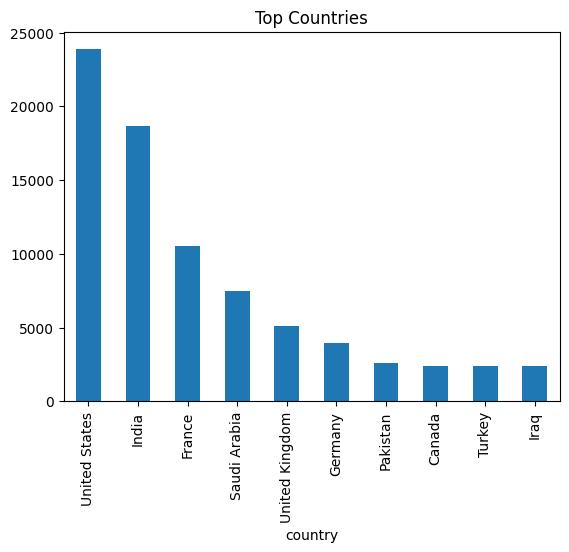

In [8]:
df['country'].value_counts().head(10).plot(kind='bar', title="Top Countries")
plt.show()

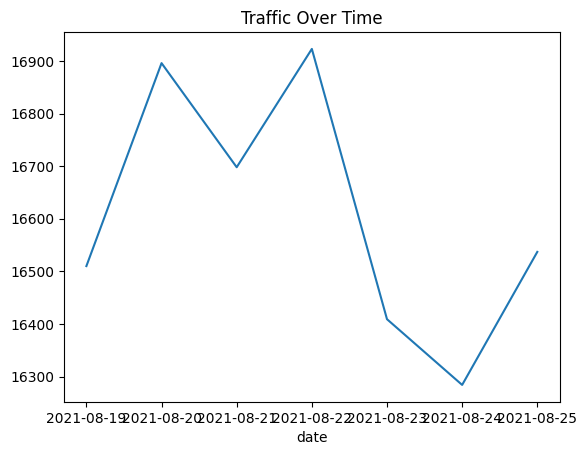

In [9]:
df.groupby(df['date'].dt.date).size().plot(kind='line', title="Traffic Over Time")
plt.show()

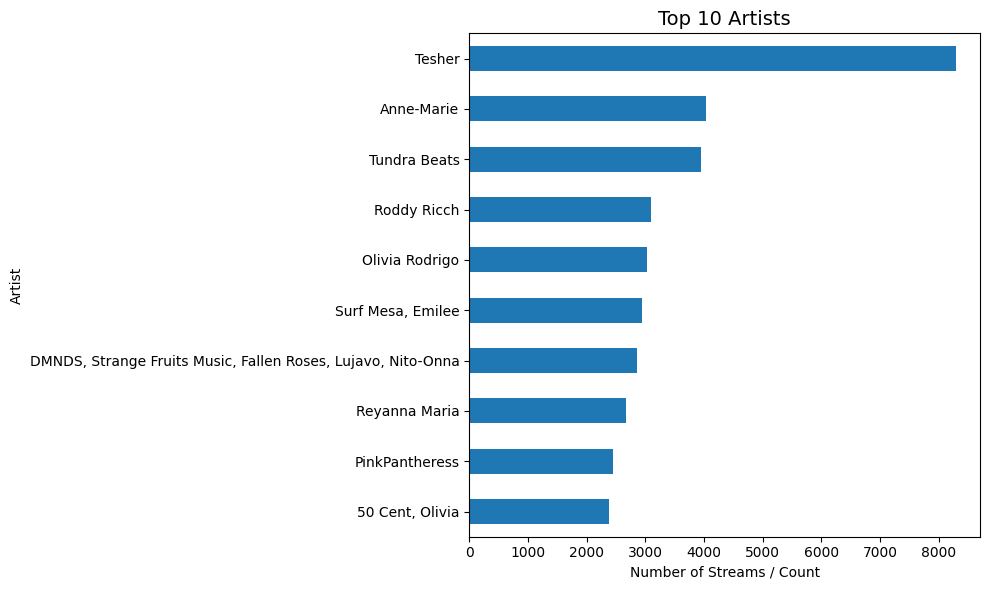

In [14]:
top_artists = df['artist'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_artists.plot(
    kind='barh',          # horizontal bar (better readability)
)

plt.title("Top 10 Artists", fontsize=14)
plt.xlabel("Number of Streams / Count")
plt.ylabel("Artist")

plt.gca().invert_yaxis()   # highest value on top

plt.tight_layout()
plt.show()

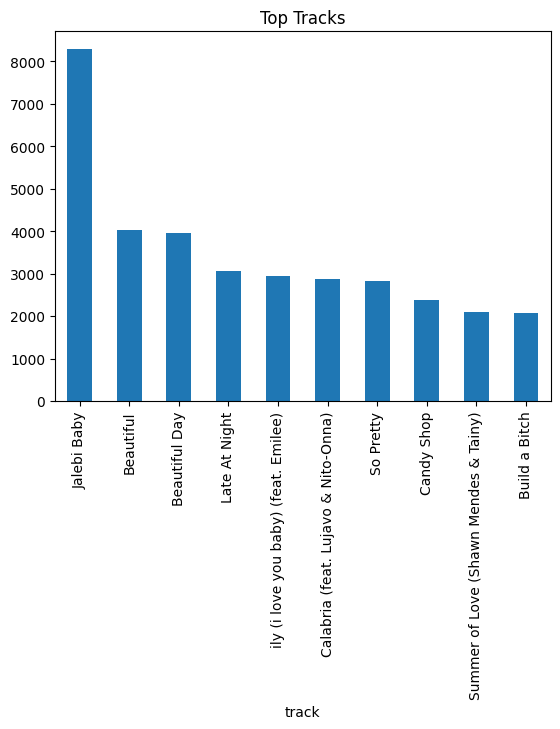

In [11]:
df['track'].value_counts().head(10).plot(kind='bar', title="Top Tracks")
plt.show()

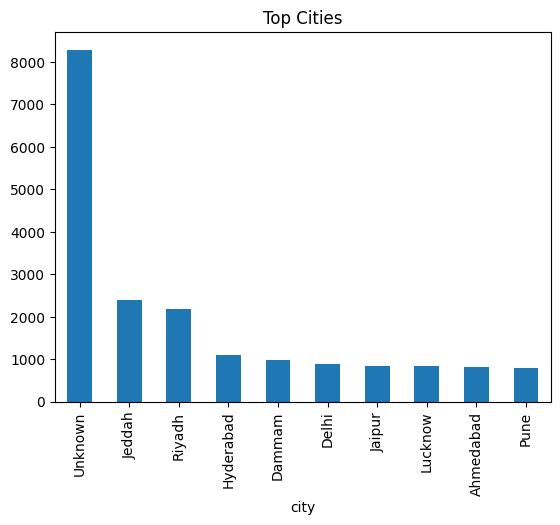

In [12]:
df['city'].value_counts().head(10).plot(kind='bar', title="Top Cities")
plt.show()

In [13]:
user_flow = df.groupby('linkid')['track'].apply(list)

print(user_flow.head())

linkid
006af6a0-1f0d-4b0c-93bf-756af9071c06    [dear katara, dear katara, dear katara, dear k...
00759b81-3f04-4a61-b934-f8fb3185f4a0    [Primero Yo, Primero Yo, Primero Yo, Primero Y...
00829040-ee01-4409-966d-d67c7965144a    [Beautiful Soul, Beautiful Soul, Beautiful Sou...
009193ee-c3df-4efa-88f2-feb37c0bfdf2    [Ain't It Fun, Ain't It Fun, Ain't It Fun, Ain...
00de7566-f014-4d20-8616-82e4dea45b88    [Wiggle feat Snoop Dogg, Wiggle feat Snoop Dog...
Name: track, dtype: object
